In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg

from multipred.plotting import barplot_morey, analyze_attention_ROI, plot_decoding_nvoxels

In [2]:
PROJECT_PATH = "/media/wiseman/tocho/multipred-fmri"
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "EVC"

## Comparing decoding across ROI sizes

24 subjects in 50 voxels mask. Visual modality: t(23)=3.8526, p=0.0004. Auditory modality: t(23)=1.7065, p=0.0945
24 subjects in 100 voxels mask. Visual modality: t(23)=4.9108, p=0.0000. Auditory modality: t(23)=4.3278, p=0.0001
23 subjects in 150 voxels mask. Visual modality: t(22)=6.4608, p=0.0000. Auditory modality: t(22)=3.9624, p=0.0003
23 subjects in 200 voxels mask. Visual modality: t(22)=6.2898, p=0.0000. Auditory modality: t(22)=5.0205, p=0.0000
23 subjects in 250 voxels mask. Visual modality: t(22)=6.9007, p=0.0000. Auditory modality: t(22)=5.5404, p=0.0000
25 subjects in wholeROI voxels mask. Visual modality: t(24)=5.7604, p=0.0000. Auditory modality: t(24)=3.9463, p=0.0003


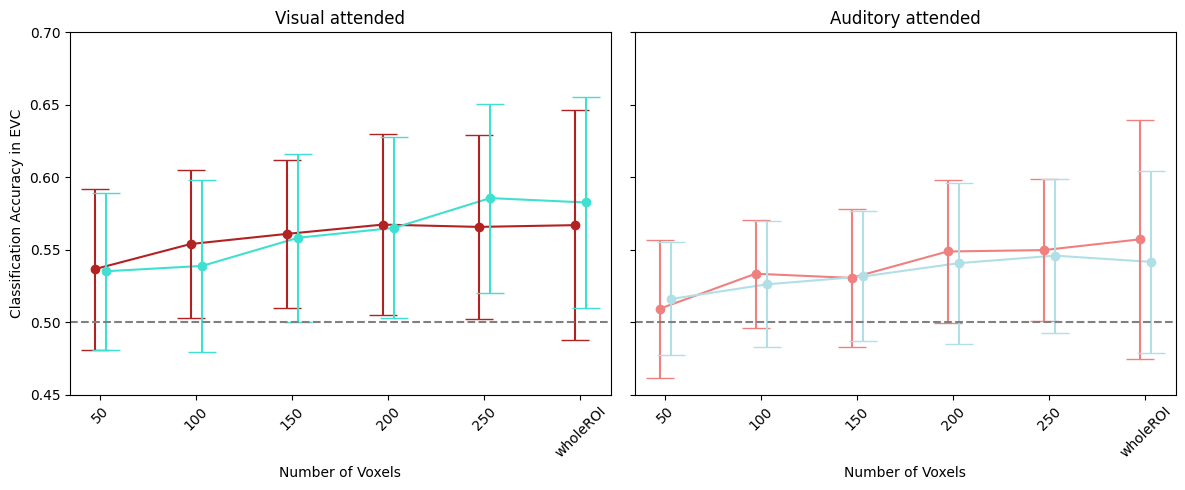

In [7]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    # "300",
    # "350",
    # "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_nvoxels(DATA_PATH, n_voxels_list, ROI, "v_pred", save_fig=False)

## Analyze specific ROIs

In [3]:
ROI = "EVC"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[
    "correct"
].mean()

### Attention * visual prediction

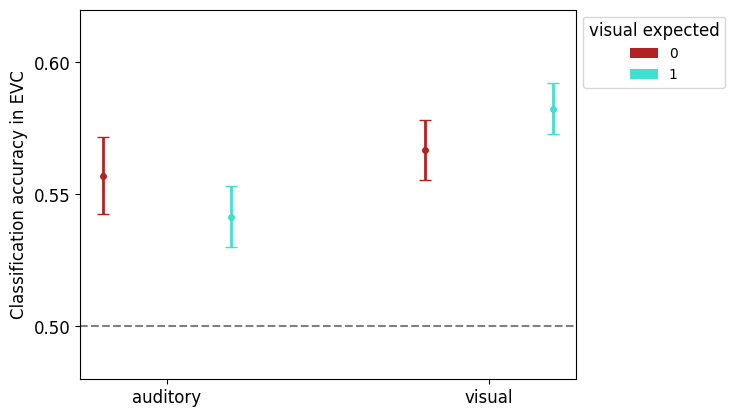

In [4]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False)
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in EVC")
plt.ylim(0.48, 0.62)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--")

In [7]:
df["correct"].mean()

np.float64(0.5620166666666667)

In [10]:
df.groupby(["modality"])["correct"].mean()

modality
auditory    0.549312
visual      0.574721
Name: correct, dtype: float64

In [6]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,1.613959e-02,1,24,1.613959e-02,3.725103,0.065501,0.065501,2.005266e-02,1.0
1,v_pred,8.506944e-08,1,24,8.506944e-08,0.000022,0.996300,0.996300,1.078575e-07,1.0
2,modality * v_pred,6.071007e-03,1,24,6.071007e-03,2.557319,0.122868,0.122868,7.638489e-03,1.0


In [7]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.930053,24.0,two-sided,0.065501,NaN,NaN,1.037,-0.306600
1,v_pred,-,0,1,True,True,-0.004685,24.0,two-sided,0.996300,NaN,NaN,0.211,-0.000710
2,modality * v_pred,auditory,0,1,True,True,0.837512,24.0,two-sided,0.410568,0.410568,fdr_bh,0.29,0.171849
3,modality * v_pred,visual,0,1,True,True,-1.251142,24.0,two-sided,0.222942,0.410568,fdr_bh,0.423,-0.166752


### Multimodal analyses

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean

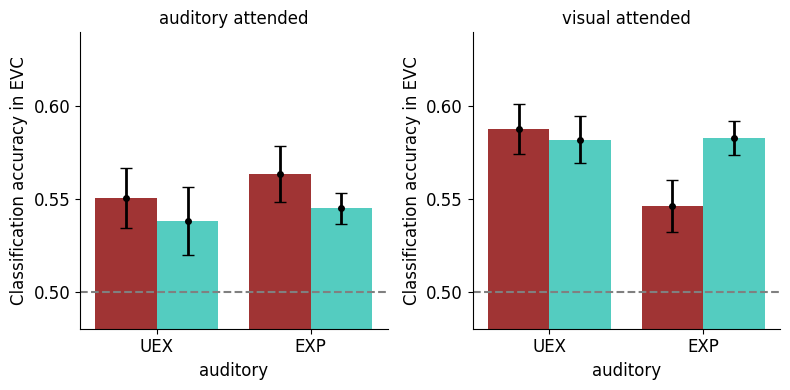

In [4]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = True
ylim = (0.48, 0.64)
yticks = [0.5, 0.55, 0.6]

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "visual expected", id, ROI, save_fig, ylim, yticks
)

In [5]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,a_pred,0.002446,1,24,0.002446,0.518588,0.478400,0.478400,0.002533,1.0
1,auditory attended,1,v_pred,0.006026,1,24,0.006026,0.701427,0.410568,0.410568,0.006217,1.0
2,auditory attended,2,a_pred * v_pred,0.000249,1,24,0.000249,0.065792,0.799752,0.799752,0.000259,1.0
3,visual attended,0,a_pred,0.010396,1,24,0.010396,2.654435,0.116318,0.116318,0.010223,1.0
4,visual attended,1,v_pred,0.006117,1,24,0.006117,1.565357,0.222942,0.222942,0.006041,1.0
5,visual attended,2,a_pred * v_pred,0.011351,1,24,0.011351,2.895391,0.101755,0.101755,0.011153,1.0


In [6]:
posthoc_df

,level_0,level_1,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,cohen
0,auditory attended,0,a_pred,-,0,1,True,True,-0.720131,24.0,two-sided,0.478400,NaN,NaN,0.267,-0.118749
1,auditory attended,1,v_pred,-,0,1,True,True,0.837512,24.0,two-sided,0.410568,NaN,NaN,0.29,0.174591
2,auditory attended,2,a_pred * v_pred,0,0,1,True,True,0.457677,24.0,two-sided,0.651301,0.651301,fdr_bh,0.232,0.106763
3,auditory attended,3,a_pred * v_pred,1,0,1,True,True,1.157871,24.0,two-sided,0.258310,0.516620,fdr_bh,0.384,0.229097
4,visual attended,0,a_pred,-,0,1,True,True,1.629244,24.0,two-sided,0.116318,NaN,NaN,0.671,0.220832
5,visual attended,1,v_pred,-,0,1,True,True,-1.251142,24.0,two-sided,0.222942,NaN,NaN,0.423,-0.169413
6,visual attended,2,a_pred * v_pred,0,0,1,True,True,0.299249,24.0,two-sided,0.767326,0.767326,fdr_bh,0.22,0.050743
7,visual attended,3,a_pred * v_pred,1,0,1,True,True,-2.258579,24.0,two-sided,0.033274,0.066549,fdr_bh,1.773,-0.400871


In [8]:
df_grouped.groupby(["modality", "a_pred", "v_pred"])["correct"].mean().unstack()

/tmp/ipykernel_1028381/721470050.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped.groupby(["modality", "a_pred", "v_pred"])["correct"].mean().unstack()


v_pred                 0         1
modality a_pred                   
auditory 0       0.55055  0.538183
         1       0.56360  0.544917
visual   0       0.58775  0.582083
         1       0.54605  0.583000